
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, March 22nd** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms,
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project.


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence.

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter.

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string:
> `"headline [SEP] short_description"`.
>
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [1]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:
# If needed (in a new env):
#!pip install -U datasets pillow

In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets.


---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [4]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [5]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [6]:
ex.keys()

dict_keys(['category', 'headline', 'authors', 'link', 'short_description', 'date'])

#### **Print 10 random samples (combined text with separator, no truncation)**

In [7]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!).

In [8]:
# huff.save_to_disk("huffpost_splits")        # save
# from datasets import load_from_disk
# huff = load_from_disk("huffpost_splits")  # reload when needed

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


In [9]:
# ============================================================
# EDA: Inspection / Sample
# ============================================================

# Encode category string labels as integer ClassLabels
huff_all = huff_all.class_encode_column("category")
label_names = huff_all.features["category"].names
num_classes = len(label_names)

print(f"Number of classes : {num_classes}")
print(f"First 5 labels    : {label_names[:5]}")
print(f"All labels        : {label_names}")



Casting to class labels:   0%|          | 0/200853 [00:00<?, ? examples/s]

Number of classes : 41
First 5 labels    : ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE']
All labels        : ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']


In [10]:
# ============================================================
# EDA: Inspection / Sample
# ============================================================

# Build combined text: "headline [SEP] short_description"
SEP = "[SEP]"

def combine_text(example):
    headline = (example["headline"] or "").strip()
    desc     = (example["short_description"] or "").strip()
    example["text"] = f"{headline} {SEP} {desc}"
    return example

huff_all = huff_all.map(combine_text)

# Verify
print("Sample combined texts:")
for i in range(3):
    print(f"\n  [{i}] {huff_all[i]['text'][:120]}")
    print(f"       → Label ID : {huff_all[i]['category']}")
    print(f"       → Label Name: {label_names[huff_all[i]['category']]}")


Map:   0%|          | 0/200853 [00:00<?, ? examples/s]

Sample combined texts:

  [0] There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV [SEP] She left her husband. He killed their children. J
       → Label ID : 6
       → Label Name: CRIME

  [1] Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song [SEP] Of course it has a song.
       → Label ID : 10
       → Label Name: ENTERTAINMENT

  [2] Hugh Grant Marries For The First Time At Age 57 [SEP] The actor and his longtime girlfriend Anna Eberstein tied the knot
       → Label ID : 10
       → Label Name: ENTERTAINMENT


Most common  : POLITICS             (32,739)
Least common : EDUCATION            (1,004)
Median count : 3,405
Imbalance ratio (max/median): 9.61x


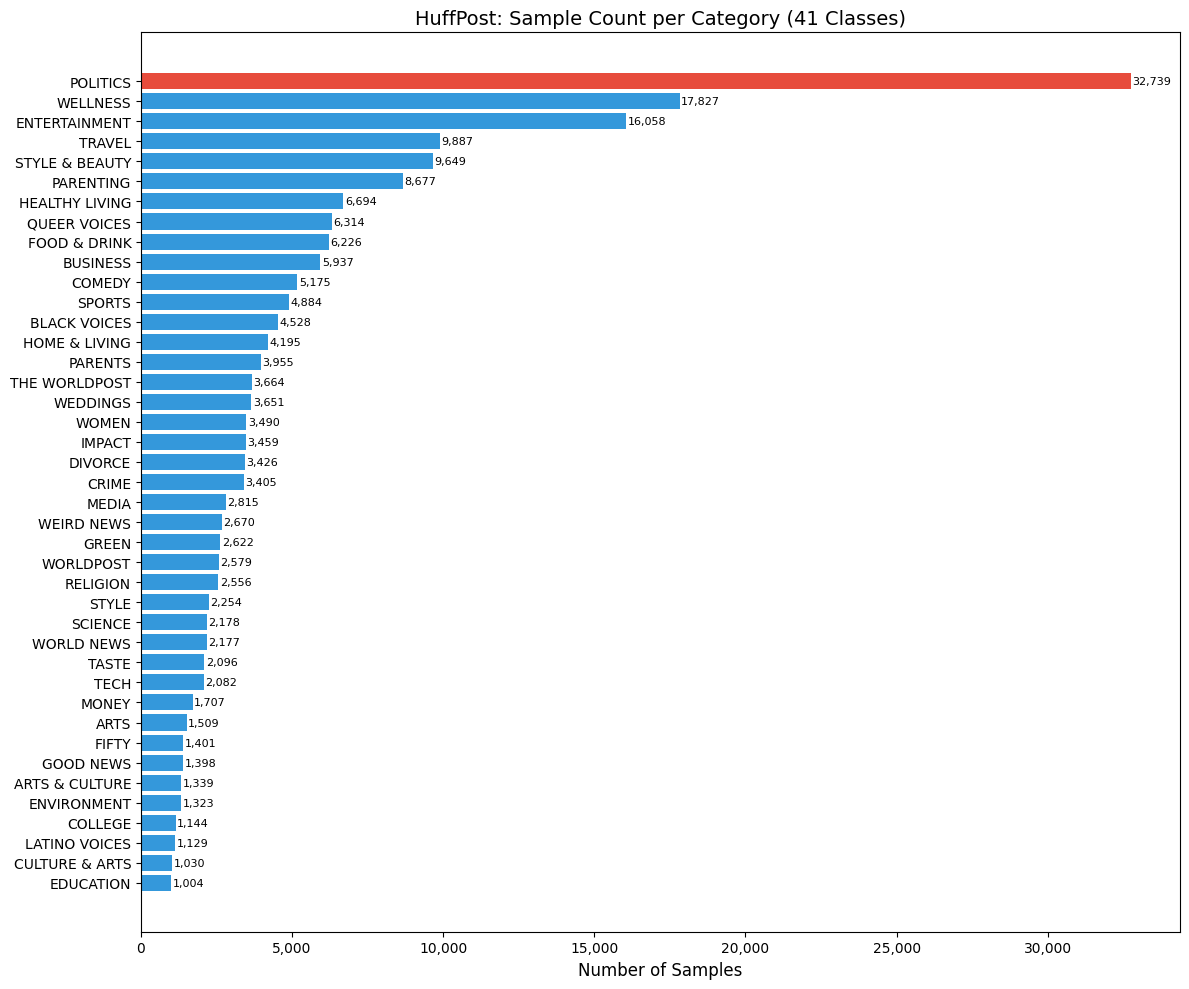

In [11]:
# ============================================================
# EDA: Class Distribution
# ============================================================

labels_list = huff_all["category"]
counts = Counter(labels_list)

# Sort by count descending
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
names  = [label_names[idx] for idx, _ in sorted_counts]
values = [cnt for _, cnt in sorted_counts]

# Imbalance statistics
max_count    = max(values)
min_count    = min(values)
median_count = int(np.median(values))
imbalance_ratio = max_count / median_count

print(f"Most common  : {names[0]:<20} ({max_count:,})")
print(f"Least common : {names[-1]:<20} ({min_count:,})")
print(f"Median count : {median_count:,}")
print(f"Imbalance ratio (max/median): {imbalance_ratio:.2f}x")

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
colors = ["#e74c3c" if v == max_count
          else "#f39c12" if v < 1000
          else "#3498db" for v in values]
ax.barh(names[::-1], values[::-1], color=colors[::-1])
ax.set_xlabel("Number of Samples", fontsize=12)
ax.set_title("HuffPost: Sample Count per Category (41 Classes)", fontsize=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (v, n) in enumerate(zip(values[::-1], names[::-1])):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


Word count statistics (combined text):
  Mean   : 30.3
  Std    : 14.0
  Min    : 1
  Max    : 246

  50th percentile : 29 words
  75th percentile : 36 words
  90th percentile : 50 words
  95th percentile : 57 words
  99th percentile : 68 words

Estimated truncation rates at candidate max_length values:
  max_length=  32 : 36.7% of records truncated
  max_length=  64 : 1.6% of records truncated
  max_length= 128 : 0.1% of records truncated
  max_length= 256 : 0.0% of records truncated
  max_length= 512 : 0.0% of records truncated


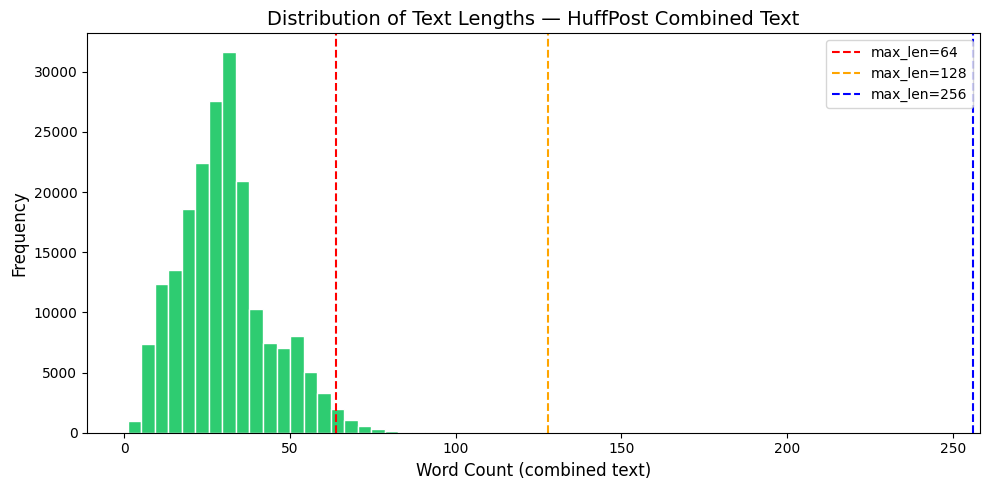

In [12]:
# ============================================================
# EDA: Text Length Analysis
# ============================================================
word_counts = [len(t.split()) for t in huff_all["text"]]
wc = np.array(word_counts)

# Statistics
print("Word count statistics (combined text):")
print(f"  Mean   : {wc.mean():.1f}")
print(f"  Std    : {wc.std():.1f}")
print(f"  Min    : {wc.min()}")
print(f"  Max    : {wc.max()}")
print()
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile : {np.percentile(wc, p):.0f} words")

# Truncation rate estimates
print("\nEstimated truncation rates at candidate max_length values:")
for max_len in [32, 64, 128, 256, 512]:
    rate = (wc > max_len).mean() * 100
    print(f"  max_length={max_len:>4} : {rate:.1f}% of records truncated")

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(wc, bins=60, color="#2ecc71", edgecolor="white")
for thresh, color, label in [(64, "red", "64"),
                              (128, "orange", "128"),
                              (256, "blue", "256")]:
    ax.axvline(thresh, color=color, linestyle="--", linewidth=1.5, label=f"max_len={label}")
ax.set_xlabel("Word Count (combined text)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Text Lengths — HuffPost Combined Text", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# EDA: Data Quality Checks
# ============================================================

df = huff_all.to_pandas()

# --- Null / empty checks
null_headline = df["headline"].isna().sum() + (df["headline"].str.strip() == "").sum()
null_desc     = df["short_description"].isna().sum() + (df["short_description"].str.strip() == "").sum()
null_category = df["category"].isna().sum()

print("=== Missing / Empty Values ===")
print(f"  Empty/null headlines          : {null_headline:,}")
print(f"  Empty/null short_descriptions : {null_desc:,}")
print(f"  Null categories               : {null_category:,}")

# --- Exact duplicates on combined text
dup_count = df["text"].duplicated().sum()
print(f"\n=== Duplicate Entries ===")
print(f"  Exact duplicate text entries  : {dup_count:,}  ({dup_count/len(df)*100:.2f}%)")

# --- Very short entries
short_mask = df["text"].str.split().str.len() < 5
short_count = short_mask.sum()
print(f"\n=== Suspiciously Short Entries (< 5 words) ===")
print(f"  Count : {short_count:,}")
print(f"\n  Sample short entries:")
display(df[short_mask][["headline", "short_description", "category"]].head(5))

# --- Preview duplicate examples
print("\n=== Sample Duplicate Entries ===")
display(df[df["text"].duplicated(keep=False)]
        [["headline", "short_description", "category"]]
        .sort_values("headline")
        .head(6))


=== Missing / Empty Values ===
  Empty/null headlines          : 6
  Empty/null short_descriptions : 19,712
  Null categories               : 0

=== Duplicate Entries ===
  Exact duplicate text entries  : 488  (0.24%)

=== Suspiciously Short Entries (< 5 words) ===
  Count : 473

  Sample short entries:


,headline,short_description,category
25814,The Bechdel Test,,5
34712,Pet Health Insurance,,3
34714,Health Care Reform,,24
35276,Constitutional Crossroads,,5
37835,Home for Christmas,,18



=== Sample Duplicate Entries ===


,headline,short_description,category
95001,,,40
101479,,,20
113471,,,25
82270,,,24
100426,,,3
198172,'Black Love' Wedding Announcements (PHOTOS),"""Black Love"" Wedding Announcements: Getting ma...",2


In [15]:
# ============================================================
# EDA: Overlapping / Ambiguous Category Examples
# ============================================================

overlap_pairs = [
    ("ARTS", "ARTS & CULTURE"),
    ("ARTS & CULTURE", "CULTURE & ARTS"),
    ("THE WORLDPOST", "WORLDPOST"),
    ("WORLDPOST", "WORLD NEWS"),
    ("PARENTS", "PARENTING"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("STYLE", "STYLE & BEAUTY"),
    ("TASTE", "FOOD & DRINK"),
]

for cat_a, cat_b in overlap_pairs:
    if cat_a in label_names and cat_b in label_names:
        idx_a = label_names.index(cat_a)
        idx_b = label_names.index(cat_b)

        count_a = counts[idx_a]
        count_b = counts[idx_b]

        sample_a = df[df["category"] == idx_a][["headline", "short_description"]].sample(
            min(2, count_a), random_state=42)
        sample_b = df[df["category"] == idx_b][["headline", "short_description"]].sample(
            min(2, count_b), random_state=42)

        print(f"\n{'='*65}")
        print(f"  [{cat_a}] ({count_a:,} samples)  vs  [{cat_b}] ({count_b:,} samples)")
        print(f"\n  {cat_a} examples:")
        for _, row in sample_a.iterrows():
            print(f"    • {row['headline']}")
            print(f"      {str(row['short_description'])[:100]}")
        print(f"\n  {cat_b} examples:")
        for _, row in sample_b.iterrows():
            print(f"    • {row['headline']}")
            print(f"      {str(row['short_description'])[:100]}")



  [ARTS] (1,509 samples)  vs  [ARTS & CULTURE] (1,339 samples)

  ARTS examples:
    • Demiurge
      I have now and then heard artists likened to the demiurge - Plato's word for the divinity that made 
    • Why You Need Painting to Say That Painting Is Dead
      I'm a painter, so of course I find statements about the death of painting annoying, but also sloppy 

  ARTS & CULTURE examples:
    • St. Vincent's Sleek Ernie Ball Collaboration Is An 'Equal-Opportunity' Guitar
      Because — duh — all guitars are.
    • Here’s What Happened When We Played Pokémon Go At MoMA
      The wildly popular video game gets a new look in a museum.

  [ARTS & CULTURE] (1,339 samples)  vs  [CULTURE & ARTS] (1,030 samples)

  ARTS & CULTURE examples:
    • St. Vincent's Sleek Ernie Ball Collaboration Is An 'Equal-Opportunity' Guitar
      Because — duh — all guitars are.
    • Here’s What Happened When We Played Pokémon Go At MoMA
      The wildly popular video game gets a new look in a museum.

  C

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Your answer here:**

The HuffPost News Category dataset contains 200,853 short news records spanning 41 topical
categories such as POLITICS, ENTERTAINMENT, PARENTING, and CRIME. Each record includes a
headline and a short description, which we concatenate as "headline [SEP] short_description"
to form a single input string — mirroring conventions used in transformer models such as BERT.
The business task is multi-class news topic classification: given a headline and brief summary,
automatically assign the correct editorial category. This has direct real-world value in content
routing, recommendation systems, and editorial workflow automation at news organizations.



2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Your answer here:**

Several issues stood out immediately during EDA. First, the dataset is significantly
class-imbalanced: POLITICS dominates with 32,739 samples while EDUCATION has only 1,004,
yielding an imbalance ratio of 9.61x. Second, 19,712 records (9.81%) have empty
short_descriptions, reducing those inputs to headline-only strings. Third, 488 exact duplicate
text entries (0.24%) exist, which must be removed before splitting to prevent data leakage.
Finally, 473 entries contain fewer than 5 words total, providing minimal signal for
classification.



3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Your answer here:**

Three primary challenges were identified. (1) Class imbalance: with a 9.61x imbalance ratio,
a naive model will bias toward dominant categories like POLITICS and WELLNESS, artificially
inflating accuracy while performing poorly on minority classes like EDUCATION and ARTS.
(2) Label overlap and noise: multiple near-duplicate category pairs exist — ARTS / ARTS &
CULTURE / CULTURE & ARTS, THE WORLDPOST / WORLDPOST / WORLD NEWS, and PARENTS / PARENTING —
totaling thousands of samples split across labels that share nearly identical vocabulary.
Additionally, mislabeled records exist (e.g., a sexual misconduct story labeled TASTE),
introducing label noise. (3) Missing descriptions: 9.81% of records lack a short_description,
degrading the combined text field and reducing classification signal for nearly 1 in 10 samples.



4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Your answer here:**

To address the identified challenges, we propose the following: (1) Deduplicate on the combined
text field before splitting to eliminate 488 exact duplicate records and prevent data leakage.
(2) Use stratified train/validation/test splits (70/15/15) with a fixed random seed of 42 to
preserve class proportions across all splits. (3) Apply class weighting during training to
penalize misclassification of minority classes equally to majority classes. (4) Set
max_length=128 tokens for tokenization — at this threshold only 0.1% of records are truncated,
capturing virtually the full dataset. (5) Flag or consolidate near-duplicate label pairs
(e.g., PARENTS/PARENTING, ARTS/ARTS & CULTURE) as a potential label-cleaning step prior to
modeling.



5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Your answer here:**

We selected HuffPost over Food-101 for three reasons. First, text classification aligns directly
with our team's prior coursework in tokenization, embeddings, and NLP preprocessing, giving us
a stronger foundation to build on. Second, the dataset is computationally lighter — no
GPU-intensive image decoding, resizing, or augmentation pipelines are required. Third, the
41-class structure with real-world label noise and class imbalance presents a richer analytical
challenge, offering more meaningful opportunities to evaluate model performance through macro-F1,
per-class precision/recall, and a full 41×41 confusion matrix in later milestones.




## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [23]:
# ============================================================
# Problem 2: Class Imbalance Summary Table
# ============================================================
imbalance_df = pd.DataFrame({
    "Category": names,
    "Count": values,
    "% of Dataset": [round(v/len(df)*100, 2) for v in values]
}).reset_index(drop=True)

imbalance_df["Flag"] = imbalance_df["Count"].apply(
    lambda x: "Dominant" if x > 15000
    else ("Minority" if x < 1500 else "Normal")
)

def color_flag(val):
    if val == "Dominant":
        return "color: red; font-weight: bold"
    elif val == "Minority":
        return "color: orange; font-weight: bold"
    return "color: green"

print(f"Imbalance Ratio (max/median): {imbalance_ratio:.2f}x")
print(f"Dominant classes (>15,000)  : {(imbalance_df['Count'] > 15000).sum()}")
print(f"Minority classes (<1,500)   : {(imbalance_df['Count'] < 1500).sum()}")
display(imbalance_df.style.applymap(color_flag, subset=["Flag"]))


Imbalance Ratio (max/median): 9.61x
Dominant classes (>15,000)  : 3
Minority classes (<1,500)   : 8


/tmp/ipykernel_3022/982122165.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(imbalance_df.style.applymap(color_flag, subset=["Flag"]))


,Category,Count,% of Dataset,Flag
0,POLITICS,32739,16.300000,Dominant
1,WELLNESS,17827,8.880000,Dominant
2,ENTERTAINMENT,16058,7.990000,Dominant
3,TRAVEL,9887,4.920000,Normal
4,STYLE & BEAUTY,9649,4.800000,Normal
5,PARENTING,8677,4.320000,Normal
6,HEALTHY LIVING,6694,3.330000,Normal
7,QUEER VOICES,6314,3.140000,Normal
8,FOOD & DRINK,6226,3.100000,Normal
9,BUSINESS,5937,2.960000,Normal


In [26]:
# ============================================================
# Problem 2: Truncation Rate at Candidate max_length Values
# ============================================================
trunc_data = []
for max_len in [32, 64, 128, 256, 512]:
    truncated = (wc > max_len).sum()
    rate = truncated / len(wc) * 100
    trunc_data.append({
        "max_length": max_len,
        "Records Truncated": truncated,
        "Truncation Rate (%)": round(rate, 2),
        "Records Retained (%)": round(100 - rate, 2)
    })

trunc_df = pd.DataFrame(trunc_data)
print("Truncation Analysis — Combined Text Field:")
display(trunc_df)
print(f"\n Recommended max_length: 128 (only {trunc_df[trunc_df['max_length']==128]['Truncation Rate (%)'].values[0]}% truncation)")


Truncation Analysis — Combined Text Field:


,max_length,Records Truncated,Truncation Rate (%),Records Retained (%)
0,32,73673,36.68,63.32
1,64,3219,1.60,98.40
2,128,167,0.08,99.92
3,256,0,0.00,100.00
4,512,0,0.00,100.00



 Recommended max_length: 128 (only 0.08% truncation)


In [27]:
# ============================================================
# Problem 2: Data Quality Summary
# ============================================================
quality_data = {
    "Issue": [
        "Empty/null headlines",
        "Empty/null short_descriptions",
        "Exact duplicate text entries",
        "Entries with < 5 words",
        "Null categories"
    ],
    "Count": [null_headline, null_desc, dup_count, short_count, null_category],
    "% of Dataset": [
        round(null_headline/len(df)*100, 2),
        round(null_desc/len(df)*100, 2),
        round(dup_count/len(df)*100, 2),
        round(short_count/len(df)*100, 2),
        round(null_category/len(df)*100, 2)
    ],
    "Action": [
        "Drop records",
        "Retain — flag as headline-only",
        "Deduplicate before split",
        "Review — drop if fully empty",
        "No action needed"
    ]
}

quality_df = pd.DataFrame(quality_data)
print("Data Quality Summary:")
display(quality_df)


Data Quality Summary:


,Issue,Count,% of Dataset,Action
0,Empty/null headlines,6,0.00,Drop records
1,Empty/null short_descriptions,19712,9.81,Retain — flag as headline-only
2,Exact duplicate text entries,488,0.24,Deduplicate before split
3,Entries with < 5 words,473,0.24,Review — drop if fully empty
4,Null categories,0,0.00,No action needed


In [24]:
# ============================================================
# Problem 2: Overlapping Label Pairs Summary
# ============================================================
overlap_summary = pd.DataFrame({
    "Label A": ["PARENTS", "THE WORLDPOST", "WORLDPOST", "ARTS", "WELLNESS", "STYLE", "TASTE"],
    "Label B": ["PARENTING", "WORLDPOST", "WORLD NEWS", "ARTS & CULTURE", "HEALTHY LIVING", "STYLE & BEAUTY", "FOOD & DRINK"],
    "Count A": [counts[label_names.index("PARENTS")],
                counts[label_names.index("THE WORLDPOST")],
                counts[label_names.index("WORLDPOST")],
                counts[label_names.index("ARTS")],
                counts[label_names.index("WELLNESS")],
                counts[label_names.index("STYLE")],
                counts[label_names.index("TASTE")]],
    "Count B": [counts[label_names.index("PARENTING")],
                counts[label_names.index("WORLDPOST")],
                counts[label_names.index("WORLD NEWS")],
                counts[label_names.index("ARTS & CULTURE")],
                counts[label_names.index("HEALTHY LIVING")],
                counts[label_names.index("STYLE & BEAUTY")],
                counts[label_names.index("FOOD & DRINK")]],
    "Severity": ["Critical", "Critical", "Critical",
                 "Critical", "High", "High", "Moderate"]
})

overlap_summary["Combined Samples"] = overlap_summary["Count A"] + overlap_summary["Count B"]

def color_severity(val):
    if val == "Critical":
        return "color: red; font-weight: bold"
    elif val == "High":
        return "color: orange; font-weight: bold"
    return "color: goldenrod; font-weight: bold"

print("Overlapping / Ambiguous Label Pairs:")
display(overlap_summary.style.applymap(color_severity, subset=["Severity"]))


Overlapping / Ambiguous Label Pairs:


/tmp/ipykernel_3022/2535608517.py:35: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(overlap_summary.style.applymap(color_severity, subset=["Severity"]))


,Label A,Label B,Count A,Count B,Severity,Combined Samples
0,PARENTS,PARENTING,3955,8677,Critical,12632
1,THE WORLDPOST,WORLDPOST,3664,2579,Critical,6243
2,WORLDPOST,WORLD NEWS,2579,2177,Critical,4756
3,ARTS,ARTS & CULTURE,1509,1339,Critical,2848
4,WELLNESS,HEALTHY LIVING,17827,6694,High,24521
5,STYLE,STYLE & BEAUTY,2254,9649,High,11903
6,TASTE,FOOD & DRINK,2096,6226,Moderate,8322


In [28]:
# ============================================================
# Problem 2: Proposed Evaluation Protocol Summary
# ============================================================
total = len(df) - dup_count
train_n = int(total * 0.70)
val_n   = int(total * 0.15)
test_n  = total - train_n - val_n

protocol_df = pd.DataFrame({
    "Property": [
        "Dataset after deduplication",
        "Train split (70%)",
        "Validation split (15%)",
        "Test split (15%)",
        "Split type",
        "Random seed",
        "Primary metric",
        "Secondary metrics"
    ],
    "Value": [
        f"{total:,}",
        f"{train_n:,}",
        f"{val_n:,}",
        f"{test_n:,}",
        "Stratified",
        "42",
        "Macro-F1",
        "Per-class Precision/Recall, Confusion Matrix"
    ]
})

print("Proposed Evaluation Protocol:")
display(protocol_df)


Proposed Evaluation Protocol:


,Property,Value
0,Dataset after deduplication,"200,365"
1,Train split (70%),"140,255"
2,Validation split (15%),"30,054"
3,Test split (15%),"30,056"
4,Split type,Stratified
5,Random seed,42
6,Primary metric,Macro-F1
7,Secondary metrics,"Per-class Precision/Recall, Confusion Matrix"


### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Your answer here:**

Given a news headline and short description, the model will predict which one of the 41
HuffPost news categories the article belongs to. This is a multiclass text classification
problem. In applied terms, the goal is to automatically tag incoming news content so it can
be routed, organized, searched, and recommended more efficiently.


2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Your answer here:**

The input will be the combined text field created from the article headline and short
description in the format "headline [SEP] short_description." For modeling, this text will
be tokenized and converted into input IDs with attention masks, then padded or truncated to
a fixed maximum length of 128 tokens. The output will be a single categorical label
representing one of the 41 HuffPost topic classes, such as POLITICS, WELLNESS,
ENTERTAINMENT, or CRIME.


3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Your answer here:**

Several challenges are likely to affect model performance. First, the dataset is imbalanced:
POLITICS contains 32,739 samples while EDUCATION contains only 1,004, giving a max/median
imbalance ratio of 9.61x and increasing the risk that a model will favor dominant classes.
Second, 19,712 records (9.81%) have empty short_descriptions, and 473 records contain fewer
than 5 words total, which reduces the amount of useful signal available for classification.
Third, 488 exact duplicate text entries create leakage risk if they are not removed before
splitting. Finally, some labels overlap heavily, such as PARENTS vs. PARENTING, WORLDPOST
vs. WORLD NEWS, and ARTS vs. ARTS & CULTURE, which will likely produce systematic confusion.



4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size).

2.4. **Your answer here:**

To address these challenges, we will first deduplicate the combined text field before any
train/validation/test split to prevent leakage. We will retain headline-only records but flag
them so we can monitor whether missing descriptions hurt performance. The text will be
tokenized with a BERT-style tokenizer and padded or truncated to max_length=128, since EDA
showed that this retains nearly the full dataset with minimal truncation. For text
representation, we plan to begin with contextual embeddings from a pretrained BERT-base model,
which uses a 768-dimensional hidden representation and should capture short news text more
effectively than manual features alone. We will also use stratified 70/15/15 splits with a
fixed random seed of 42 and apply class weighting during training to reduce bias toward large
classes. If overlapping labels remain a major source of confusion, we will revisit possible
label consolidation in Milestone 2.



5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Your answer here:**

Our primary metric will be macro-F1 because it computes F1 separately for each of the 41
classes and then averages them equally, making it more appropriate than accuracy for an
imbalanced dataset. Accuracy will still be reported as a secondary metric, but it will not
be our main measure of success because it can be inflated by dominant classes such as
POLITICS and WELLNESS. We will also examine per-class precision and recall, along with a full
41x41 confusion matrix, to identify where the model struggles most, especially among
overlapping label groups. Performance will be evaluated using a stratified 70/15/15
train/validation/test split after deduplication with a fixed random seed of 42. We will view
the model as successful if it achieves a strong macro-F1 score without large performance gaps
between majority and minority classes.


### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

